# Assignment 3: Unsupervised Learning — Vancouver Business Licences Explorer

In [12]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

## Part A — Business-Level Clustering

## A1 — Data acquisition and cleaning

In [4]:
# load geojson file
data = gpd.read_file("business-licences.geojson")
print(f"Shape: {data.shape}")
data.head()

Shape: (204301, 26)


,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,province,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geometry
0,24,4518841,24-138560,10,Nobl Collective Ltd,None,Issued,2023-12-28 21:34:28+00:00,2024-12-31,Consulting and Management Services,...,BC,CA,None,Kitsilano,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,None
1,24,4518843,24-138562,10,645064 BC Ltd,Trade Exchange Canada,Issued,2023-11-20 21:40:18+00:00,2024-12-31,Business Support Services,...,BC,CA,None,Kitsilano,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,None
2,24,4518844,24-138563,10,(Louise Turgeon),Turgeon Business Consulting,Issued,2023-11-21 22:30:07+00:00,2024-12-31,Consulting and Management Services,...,BC,CA,None,Downtown,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,None
3,24,4518848,24-138567,10,Baron Global Financial Canada Ltd,None,Issued,2023-12-11 18:12:12+00:00,2024-12-31,Consulting and Management Services,...,BC,CA,V6E 2E9,Downtown,5.0,NaN,2026-07-01 02:32:17-07:00,None,"{'lon': -123.118192793095, 'lat': 49.287734201...",POINT (-123.11819 49.28773)
4,24,4518856,24-138576,10,Jennifer D S Dezell (Jennifer Dezell),Dentons Canada LLP,Issued,2023-12-09 00:34:17+00:00,2024-12-31,Legal Services,...,BC,CA,V6C 3R8,Downtown,217.0,NaN,2026-07-01 02:32:17-07:00,None,"{'lon': -123.113252488858, 'lat': 49.286652613...",POINT (-123.11325 49.28665)


In [7]:
# inspect structure
print("Column dtypes:\n", data.dtypes)
print("\nGeometry types:\n", data.geometry.type.value_counts(dropna=False))
print("\nCRS:", data.crs)

Column dtypes:
 folderyear                                  object
licencersn                                  object
licencenumber                               object
licencerevisionnumber                       object
businessname                                object
businesstradename                           object
status                                      object
issueddate                     datetime64[ms, UTC]
expireddate                         datetime64[ms]
businesstype                                object
businesssubtype                             object
unit                                        object
unittype                                    object
house                                       object
street                                      object
city                                        object
province                                    object
country                                     object
postalcode                                  object
localarea      

In [26]:
# inspect missingness
missing_summary = pd.DataFrame({
    "nan vals": data.isna().sum(),
    "Percentage": (data.isna().sum() /len(data)*100).round(2)
}).sort_values("Percentage", ascending=False)

print("\nMissingness by column:\n", missing_summary)



Missingness by column:
                        nan vals  Percentage
geom                     204301      100.00
businesssubtype          182748       89.45
unittype                 155610       76.17
unit                     155345       76.04
businesstradename        126897       62.11
geo_point_2d             101647       49.75
geometry                 101647       49.75
postalcode                95239       46.62
house                     94501       46.26
street                    94484       46.25
feepaid                   75420       36.92
country                   45005       22.03
issueddate                28778       14.09
expireddate               28755       14.07
businessname              13483        6.60
localarea                  2714        1.33
province                     82        0.04
city                         58        0.03
businesstype                  0        0.00
status                        0        0.00
licencerevisionnumber         0        0.00
licence

### 1) A1 Analysis
The geom column is 100% missing so I'll drop this column

geometry/geo_point_2d is half missing so Ill drop those rows but figure out how many rows were lost

businesssubtype is 89.45% missing s, so the industry_label refiniement will generally go back to business type

postalcide us 46.62% missing so its not reliable as a backup for location indication

numberofemplotees has 0% missing so its all good.

feepaid is 36.92% missing so its worth adding missing flag instead of assigning any blame to it

In [5]:
# dropping rows with completely empty geom column
data=data.drop(columns=["geom"])

# dealing with records with no geographic coords
n_before=len(data)
data=data[data.geometry.notna()].copy()
n_after=len(data)
print(f"dropped {n_before -n_after} rows without any geometry "
      f"({(n_before - n_after)/n_before*100:.2f}% of dataset)")

dropped 101647 rows without any geometry (49.75% of dataset)


### 2) A1 Analysis

The reason I drop these rows is because rows with no geometry cant be mapped of used in location clustring which will be needed for the next part (A2). I've also showed here exactly how many rows were dropped

In [6]:
# dealing with missing feepaid
data["feepaid_missing"]=data["feepaid"].isna()

## 3) A1 Analysis

Fee paid is a numeric field used for context and to filter. It is not used for the main geom clustering. Dropping rows here for missing data would also take away useful location data.

Instead I'll keep the rows and flag the missingness. I wont assign a fake number for the column since that could bias the end result.

In [7]:
# filter to sensible subset
print(data["status"].value_counts())
data=data[data["status"]== "Issued"].copy()
print(f"\nRows after filtering to issued:{len(data)}")

status
Issued                  85950
Pending                  5808
Gone Out of Business     4879
Inactive                 4209
Cancelled                1808
Name: count, dtype: int64

Rows after filtering to issued:85950


### 4) A1 Analysis

I only want licences that are currently active. Pending, cancelled, or closed businesses aren't part of 'current' business activity. Mixing them in would make it harder to fairly compare which active businesses look unusual.

In [8]:
# consolidating businesstype
type_counts=data["businesstype"].value_counts()
type_pct =(type_counts/ type_counts.sum()*100)
cumulative=type_pct.cumsum()
print(type_counts.head(20))
print("\ncumulative % coverage by top n categories:")
print(cumulative.head(20))

# keeping however many categories cover 85% of records
# and bucketing the rest as "Other."
threshold = 85
top_categories =cumulative[cumulative<=threshold].index.tolist()
if len(top_categories)<len(cumulative):
    top_categories.append(cumulative.index[len(top_categories)])
print(f"\nkeeping {len(top_categories)}categories covering ~{threshold}% of data")

data["businesstype_grouped"]=data["businesstype"].where(data["businesstype"].isin(top_categories), "Other")
print(data["businesstype_grouped"].value_counts())


businesstype
Health Care Professionals and Services           11819
Long-term Rental                                 10265
Retail Dealer                                     6142
Legal Services                                    5214
Restaurant                                        4919
Beauty Services                                   3942
Limited Service Food Establishment                3818
Business Support Services                         2968
Financial Services                                2402
Consulting and Management Services                2354
Real Estate Services                              2056
Retail Dealer - Food                              1937
General Contractor                                1790
Association or Society                            1723
Information Communication Technology              1707
Wholesale Dealer - Non-Food                       1458
Parking Area / Garage                             1194
Health Care Facility                              10

## A2 — Location-only clustering: K-means vs. DBSCAN

In [9]:
#  extracting lat/lon from geometry
data["lon"]=data.geometry.x
data["lat"]=data.geometry.y
coords =data[["lat", "lon"]].dropna().copy()
print(f"rows used for clustering:{len(coords)}")

# standardizing coords to help K-means treat lat/lon on more appropriate scales
scaler=StandardScaler()
coords_scaled=scaler.fit_transform(coords[["lat", "lon"]])

rows used for clustering:85950


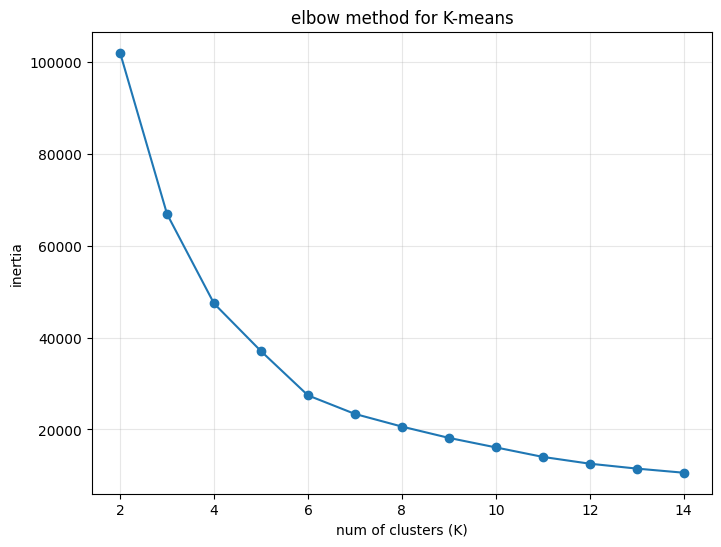

In [10]:
# elbow method to choose K
inertias= []
Krange=range(2, 15)
for k in Krange:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(coords_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(8,6))
plt.plot(list(Krange),inertias, marker="o")
plt.xlabel("num of clusters (K)")
plt.ylabel("inertia")
plt.title("elbow method for K-means")
plt.grid(True, alpha=0.3)
plt.show()

### 1) A2 Analysis

The elobow graph is showing 6 as the best K

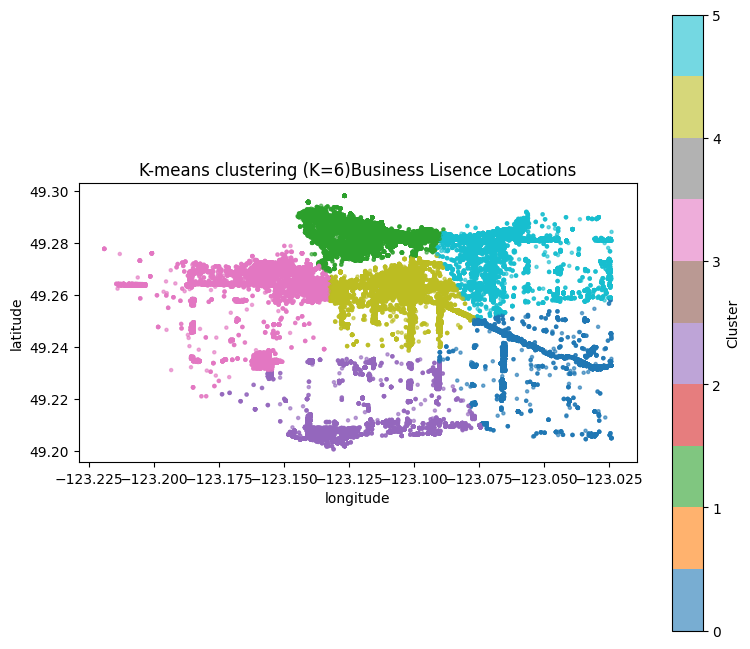

In [11]:
# fitting with K

# graph shows visible bend at K=6
K = 6

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
coords["kmeans_cluster"] =kmeans.fit_predict(coords_scaled)
plt.figure(figsize=(9,8))
scatter=plt.scatter(
    coords["lon"], coords["lat"], c=coords["kmeans_cluster"], cmap= "tab10", s=5, alpha= 0.6)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title(f"K-means clustering (K={K})Business Lisence Locations")
plt.colorbar(scatter, label= "Cluster")
plt.gca().set_aspect("equal")
plt.show()

DBSCAN found 429 clusters
noise points: 7831(9.11%)


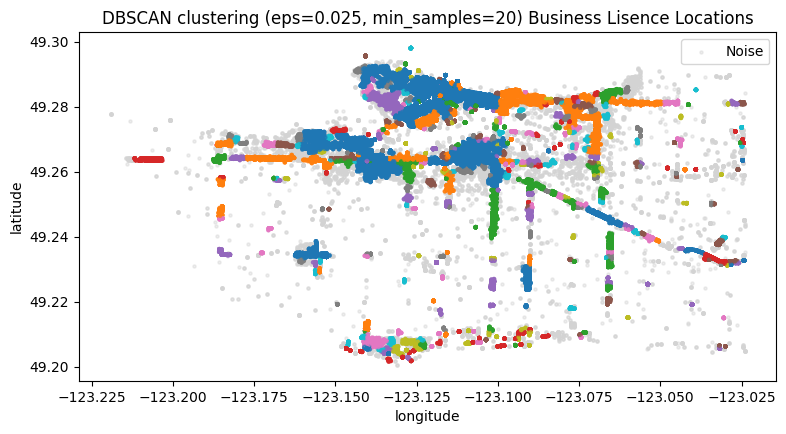

In [39]:
#  choosing eps/min_samples
dbscan = DBSCAN(eps=0.027,min_samples=20)
coords["dbscan_cluster"]=dbscan.fit_predict(coords_scaled)
n_clusters_dbscan=len(set(coords["dbscan_cluster"])) - (1 if -1 in coords["dbscan_cluster"].values else 0)
n_noise =(coords["dbscan_cluster"]== -1).sum()
print(f"DBSCAN found {n_clusters_dbscan} clusters")
print(f"noise points: {n_noise}({n_noise/len(coords)*100:.2f}%)")
plt.figure(figsize=(9, 8))

# plotting noise points initially so that actual clusters are clearly visible over top
noise_mask = coords["dbscan_cluster"]==-1
plt.scatter(coords.loc[noise_mask, "lon"], coords.loc[noise_mask, "lat"],
    c="lightgray", s=5, alpha=0.4, label="Noise")
plt.scatter(coords.loc[~noise_mask, "lon"], coords.loc[~noise_mask, "lat"],
    c=coords.loc[~noise_mask, "dbscan_cluster"], cmap="tab10", s=5, alpha=0.6)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title(f"DBSCAN clustering (eps=0.025, min_samples=20) Business Lisence Locations")
plt.gca().set_aspect("equal")
plt.legend()
plt.show()

### 2) A2 Analysis
#### How do the K-means clusters map onto actual Vancouver geography — do they correspond to anything you'd recognize (downtown core, west side, etc.)?

The K-means map splits things into 6 chunks and they roughly match how someone would naturally divide the area. The clusters look like cleanly separated areas with easily discernable borders. This is because K-means doesnt know anything about real neighborhoods. It groups points that are physically close into equal ish parts. It lines up with recognizable parts of the city but thats likely due to how the density of businesses is spread out in Vanvouver (and not the algorithm understanding the geography )

### 3) A2 Analysis

#### How do the DBSCAN clusters compare?
DBSCAN gives a completely different outcome. It found 429 tinier clisters and about 9% that was noise and didnt git into any of them.

The two methods are very different, Kmeans forces every single business into a fixed amount of groups, nothing is left out
DBSCAN only groups businesses if they are packed closely enough. If the area is not desnse enough it categorizes it as noise instead of forcing it into a group (like Kmeans does).

<br>

#### Where do the two methods agree or disagree, and why — think about what each algorithm assumes about cluster shape and density, and what DBSCAN's "noise" points represent.

I can see that both methods are picking up on the same generally busy streets. There are matching areas of high business density in both of the plots.

Where they disagree is that Kmeans smooths everything into big simple chunks, whereas DBSCAN breaks them into much smaller, precise chunks. DBSCAN also shows busninesses that dont fit into the clusters.

The noise points that arent in the clusters are more isolated businesses. This could helpful info for analysis since it tells us that the business is more alone and without many neighbors. It could mean there is somthing special or unusual about it. KMeans cannot identify these types of points since it puts every single point into a cluster.



## A3 — Feature-based clustering: Size, Industry, Lifecycle

In [15]:
# engineering and scaling features

features = data.copy()

# size features
features["numberofemployees"]=features["numberofemployees"].astype(float)
features["feepaid"]=features["feepaid"].astype(float)
features["feepaid"]=features["feepaid"].fillna(features["feepaid"].median())
features["feepaid_missing"]= data["feepaid"].isna().astype(int)

# lifecycle
features["issueddate"]=pd.to_datetime(features["issueddate"], errors="coerce",utc=True).dt.tz_localize(None)
features["expireddate"]=pd.to_datetime(features["expireddate"], errors="coerce",utc=True).dt.tz_localize(None)

# lisence duration in days
features["licence_duration_days"]=(features["expireddate"]-features["issueddate"]).dt.days

# month issued, cyclically
features["issued_month"]=features["issueddate"].dt.month
features["issued_month_sin"]=np.sin(2* np.pi*features["issued_month"]/12)
features["issued_month_cos"]=np.cos(2*np.pi*features["issued_month"]/12)

# lisence revision num
features["licencerevisionnumber"] =features["licencerevisionnumber"].astype(float)

# filling rows with missing duration or month with median instead of dropping it
features["duration_missing"]=features["licence_duration_days"].isna().astype(int)
features["licence_duration_days"] =features["licence_duration_days"].fillna(features["licence_duration_days"].median())
features["issued_month_sin"]=features["issued_month_sin"].fillna(0)
features["issued_month_cos"]=features["issued_month_cos"].fillna(0)

# industry
# swapping industry_label_grouped to try the finer version
industry_col="businesstype_grouped"
ohenc=OneHotEncoder(sparse_output=False, handle_unknown="ignore")
industry_encoded=ohenc.fit_transform(features[[industry_col]])
industry_cols=[f"industry_{c}" for c in ohenc.categories_[0] ]
industry_df=pd.DataFrame(industry_encoded, columns=industry_cols, index=features.index)
print(f"industry one hot columns:  {len(industry_cols)}")


industry one hot columns:  28


In [16]:
# combining and scaling features
numeric_features= ["numberofemployees", "feepaid", "feepaid_missing",
                   "licence_duration_days", "duration_missing",
                   "issued_month_sin","issued_month_cos",
                   "licencerevisionnumber",]
feature_df=pd.concat([features[numeric_features], industry_df], axis= 1)
scaler2=StandardScaler()
X_scaled=scaler2.fit_transform(feature_df)

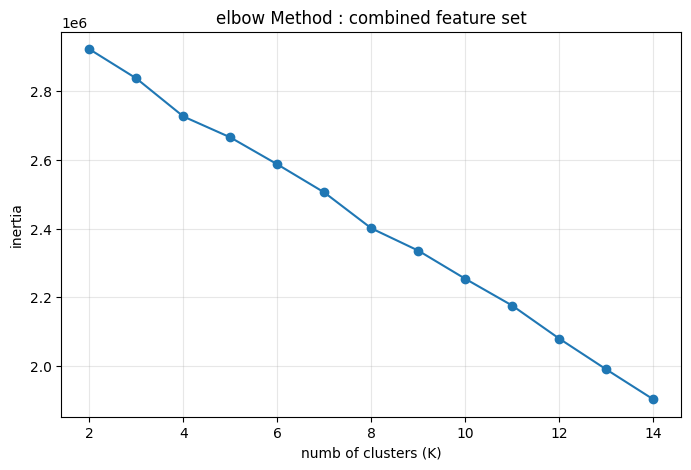

In [19]:
# running simple Kmeans clustering and appying to PCA to project to 2D and visualize clusters
# elbow method to choose K
inertias_features= []
K_range=range(2, 15)
for k in K_range:
    km=KMeans(n_clusters=k,random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias_features.append(km.inertia_)
plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias_features, marker="o")
plt.xlabel("numb of clusters (K)")
plt.ylabel("inertia")
plt.title("elbow Method : combined feature set")
plt.grid(True, alpha=0.3)
plt.show()


In [22]:
# elbow bwgins to dip relatively more than other points at 7
K_FEATURES=7
kmeans_features=KMeans(n_clusters=K_FEATURES,random_state= 42, n_init=10)
feature_df["cluster"]=kmeans_features.fit_predict(X_scaled)
print(feature_df["cluster"].value_counts())

cluster
0    36064
5    22833
3    17162
1     3818
2     2968
4     2354
6      751
Name: count, dtype: int64


explained variance ratio:[0.05969293 0.04718219]
total variance captured by 2 components:10.7%


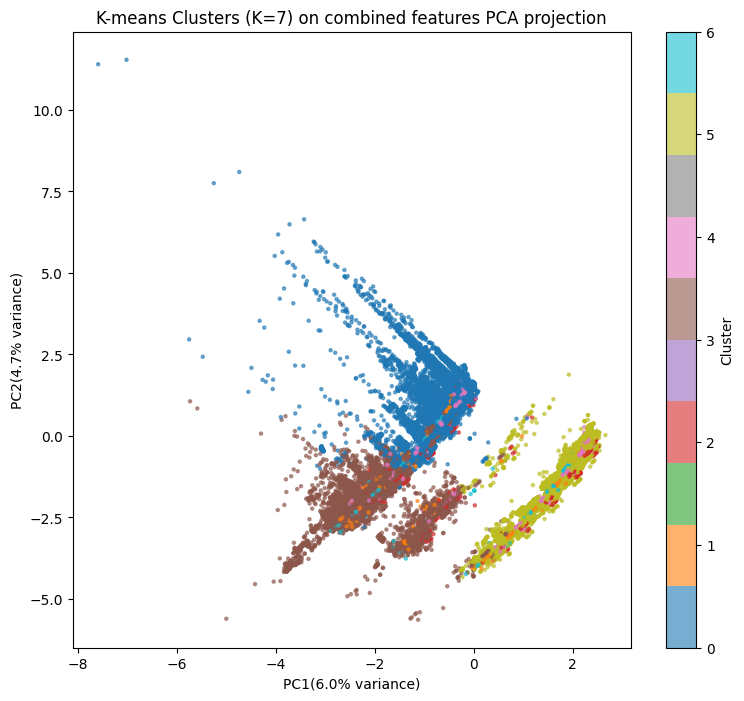

In [23]:
# PCA to 2D
pca=PCA(n_components=2, random_state=42)
X_pca=pca.fit_transform(X_scaled)
print(f"explained variance ratio:{pca.explained_variance_ratio_}")
print(f"total variance captured by 2 components:{pca.explained_variance_ratio_.sum()*100:.1f}%")
plt.figure(figsize=(9, 8))
scatter = plt.scatter( X_pca[:, 0], X_pca[:, 1], c=feature_df["cluster"], cmap="tab10", s=5, alpha=0.6)
plt.xlabel(f"PC1({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"K-means Clusters (K={K_FEATURES}) on combined features PCA projection")
plt.colorbar(scatter, label="Cluster")
plt.show()

### 1) A3 Analysis
#### What do the resulting clusters seem to represent?
When I check the cluster sizes, they line almost excactly up alnost exactly with the individual business types from earlier above. One cluster is all the Limited Service Food Establishments, another is all Business Support Services, and etc.

So instead of blending size, industry, and lifecycle like I was aiming for, Kmeans pretty much just re identified the industry categories I had.

This probabky happened because industry was turned into 27 speerate yes/no columns, whereas size and lifecycles only added a handful. With that amount of industry columns, they ended up dominating so KMeans grouped by industry mainly.

<br>

#### Does this differ from the purely geographic clustering in A2?
Yes, the A2 grouped business were put organized by their location, with no context of what kind of business they were. This one was meant to group them based on a mix of size/industry/and lifecycle (but mostly ended up showing industry as explained above)

